# 第10章 监测大数据预处理 - Python代码示例

本Notebook配合《第10章 监测大数据预处理——结构健康监测与智能传感》课件使用，通过Python代码实例演示教材中提到的三大类核心预处理方法：
1. **数据噪声预处理**：移动平均去噪、卡尔曼滤波降噪、小波变换降噪
2. **数据异常值诊断**：基于分布的诊断（3σ准则、箱形图）、基于聚类的诊断（DBSCAN）
3. **缺失数据恢复**：插值补全方法、基于压缩感知群稀疏优化的恢复（简化版）

我们将使用NumPy、Pandas进行数据处理，并使用Matplotlib进行可视化。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
from sklearn.cluster import DBSCAN
from scipy.interpolate import lagrange

# 设置中文字体以支持Matplotlib中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'WenQuanYi Micro Hei', 'Arial Unicode MS'] 
plt.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore')

## 1. 数据噪声预处理部分
本节演示：移动平均去噪（SMA与EMA）、卡尔曼滤波、小波变换降噪。

=== 1.1 移动平均去噪 ===


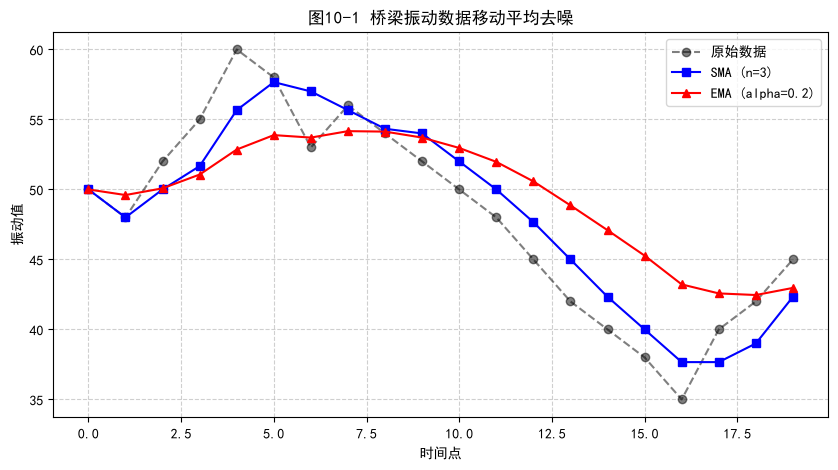

In [2]:
# 1.1 移动平均去噪（教材例10-1）
print("=== 1.1 移动平均去噪 ===")
# 原始数据
raw_data = np.array([50, 48, 52, 55, 60, 58, 53, 56, 54, 52, 
                     50, 48, 45, 42, 40, 38, 35, 40, 42, 45], dtype=float)

# (1) 简单移动平均 (SMA), 窗口 n=3
n = 3
sma_data = np.zeros_like(raw_data)
# 前两个数据由于窗口不足，这里简单保持原值或取可用数据的均值，教材中是从第三个点开始或特殊处理，我们这里用卷积实现标准的SMA
sma_data = np.convolve(raw_data, np.ones(n)/n, mode='valid')
# 补齐长度以对齐绘图
sma_plot = np.concatenate(([raw_data[0], raw_data[1]], sma_data))

# (2) 指数加权移动平均 (EMA), alpha=0.2
alpha = 0.2
ema_data = np.zeros_like(raw_data)
ema_data[0] = raw_data[0]
for t in range(1, len(raw_data)):
    ema_data[t] = alpha * raw_data[t] + (1 - alpha) * ema_data[t-1]

plt.figure(figsize=(10, 5))
plt.plot(raw_data, 'ko--', label='原始数据', alpha=0.5)
plt.plot(sma_plot, 'bs-', label='SMA (n=3)')
plt.plot(ema_data, 'r^-', label='EMA (alpha=0.2)')
plt.title('图10-1 桥梁振动数据移动平均去噪')
plt.xlabel('时间点')
plt.ylabel('振动值')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

=== 1.2 卡尔曼滤波数据降噪 ===


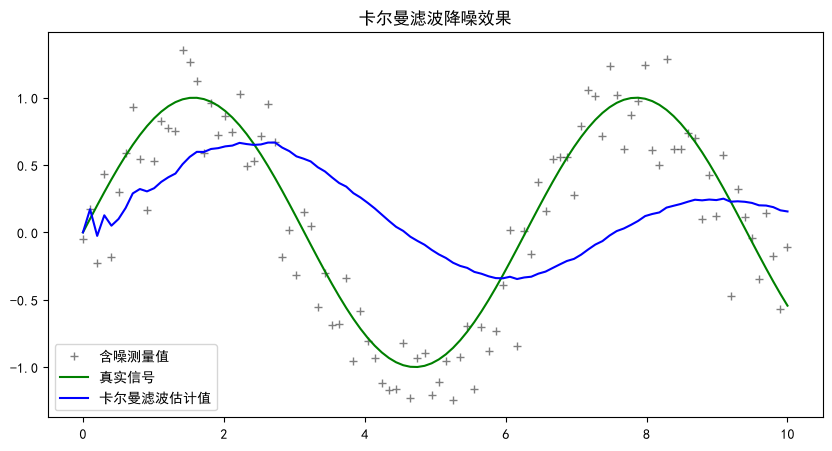

In [3]:
# 1.2 卡尔曼滤波数据降噪
print("=== 1.2 卡尔曼滤波数据降噪 ===")
# 生成带有高斯白噪声的模拟正弦信号
t = np.linspace(0, 10, 100)
true_signal = np.sin(t)
noisy_signal = true_signal + np.random.normal(0, 0.3, len(t))

# 简化的卡尔曼滤波实现 (一维状态)
n_iter = len(noisy_signal)
sz = (n_iter,)
Q = 1e-5 # 系统噪声方差
R = 0.1**2 # 观测噪声方差

xhat=np.zeros(sz)      # 状态估计值
P=np.zeros(sz)         # 估计误差方差
xhatminus=np.zeros(sz) # 预测状态估计值
Pminus=np.zeros(sz)    # 预测误差方差
K=np.zeros(sz)         # 卡尔曼增益

# 初始猜测
xhat[0] = 0.0
P[0] = 1.0

for k in range(1, n_iter):
    # 时间更新 (预测)
    xhatminus[k] = xhat[k-1]
    Pminus[k] = P[k-1] + Q
    
    # 测量更新 (校正)
    K[k] = Pminus[k] / (Pminus[k] + R)
    xhat[k] = xhatminus[k] + K[k] * (noisy_signal[k] - xhatminus[k])
    P[k] = (1 - K[k]) * Pminus[k]

plt.figure(figsize=(10, 5))
plt.plot(t, noisy_signal, 'k+', label='含噪测量值', alpha=0.5)
plt.plot(t, true_signal, 'g-', label='真实信号')
plt.plot(t, xhat, 'b-', label='卡尔曼滤波估计值')
plt.title('卡尔曼滤波降噪效果')
plt.legend()
plt.show()

=== 1.3 小波变换数据降噪 ===


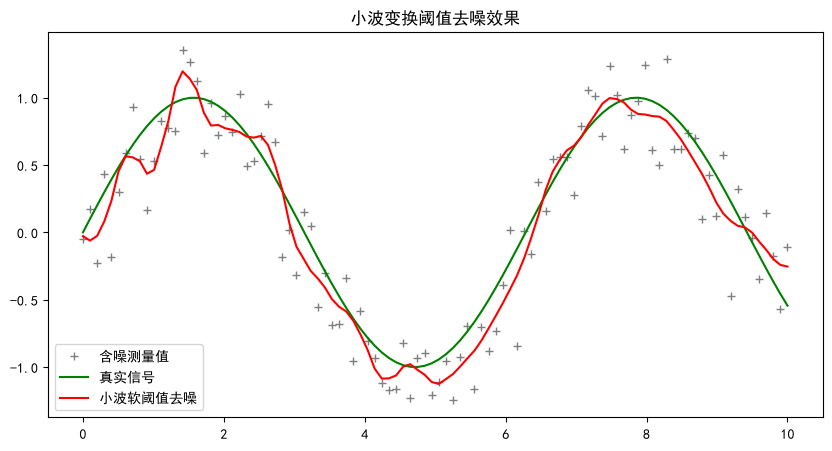

In [4]:
# 1.3 小波变换数据降噪
print("=== 1.3 小波变换数据降噪 ===")
# 使用上面生成的 noisy_signal
wavelet = 'db4' # 选用Daubechies小波
level = 2       # 分解层数

# 第一步：小波分解
coeffs = pywt.wavedec(noisy_signal, wavelet, level=level)

# 第二步：阈值处理 (使用通用阈值并采用软阈值函数)
sigma = np.median(np.abs(coeffs[-1])) / 0.6745
uthresh = sigma * np.sqrt(2 * np.log(len(noisy_signal)))
coeffs_thresh = [pywt.threshold(c, value=uthresh, mode='soft') if i > 0 else c for i, c in enumerate(coeffs)]

# 第三步：小波逆变换重构信号
denoised_signal = pywt.waverec(coeffs_thresh, wavelet)

plt.figure(figsize=(10, 5))
plt.plot(t, noisy_signal, 'k+', label='含噪测量值', alpha=0.5)
plt.plot(t, true_signal, 'g-', label='真实信号')
plt.plot(t, denoised_signal[:len(t)], 'r-', label='小波软阈值去噪')
plt.title('小波变换阈值去噪效果')
plt.legend()
plt.show()

## 2. 数据异常值诊断
本节演示：基于分布的异常值诊断（拉依达准则、箱形图）与基于聚类的异常值诊断（DBSCAN）。

=== 2.1 基于分布的异常值诊断 ===
第一天数据均值: 3.19, 标准差: 2.07
3sigma阈值范围: [-3.01, 9.38]
拉依达准则识别出的异常值: []

箱形图 Q1: 2.20, Q3: 3.00, IQR: 0.80
箱形图正常范围: [1.00, 4.20]
箱形图识别出的异常值: [7.8]


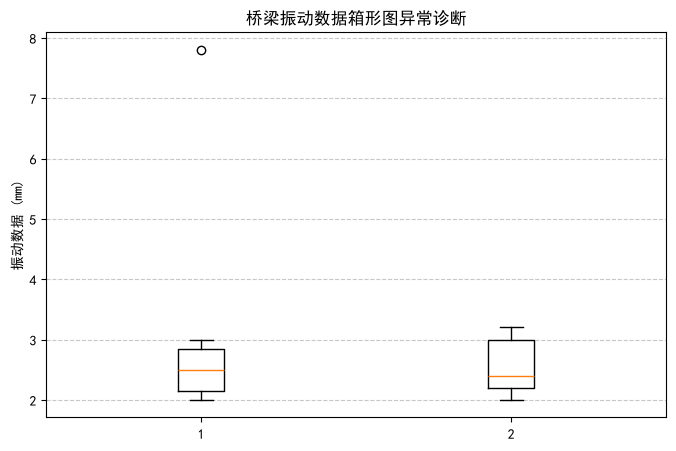

In [5]:
# 2.1 基于分布的异常值诊断（拉依达准则与箱形图）
print("=== 2.1 基于分布的异常值诊断 ===")
# 采用教材例10-2的数据
day1_data = np.array([2.1, 2.0, 2.2, 2.5, 3.0, 7.8, 2.7])
day2_data = np.array([2.0, 2.1, 2.3, 2.4, 3.1, 2.9, 3.2])

# (1) 拉依达准则 (3sigma)
mean1 = np.mean(day1_data)
std1 = np.std(day1_data, ddof=1) # 样本标准差
threshold_3sigma = 3 * std1
outliers_3sigma = day1_data[np.abs(day1_data - mean1) > threshold_3sigma]
print(f"第一天数据均值: {mean1:.2f}, 标准差: {std1:.2f}")
print(f"3sigma阈值范围: [{mean1 - threshold_3sigma:.2f}, {mean1 + threshold_3sigma:.2f}]")
print(f"拉依达准则识别出的异常值: {outliers_3sigma}")

# (2) 箱形图方法 (IQR)
Q1 = np.percentile(day1_data, 25, method='higher') # 对应教材中的位置计算
Q3 = np.percentile(day1_data, 75, method='higher')
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = day1_data[(day1_data < lower_bound) | (day1_data > upper_bound)]
print(f"\n箱形图 Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"箱形图正常范围: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"箱形图识别出的异常值: {outliers_iqr}")

# 绘制箱形图
plt.figure(figsize=(8, 5))
plt.boxplot([day1_data, day2_data], label=['第一天', '第二天'])
plt.title('桥梁振动数据箱形图异常诊断')
plt.ylabel('振动数据 (mm)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

=== 2.2 基于聚类的异常值诊断 (DBSCAN) ===


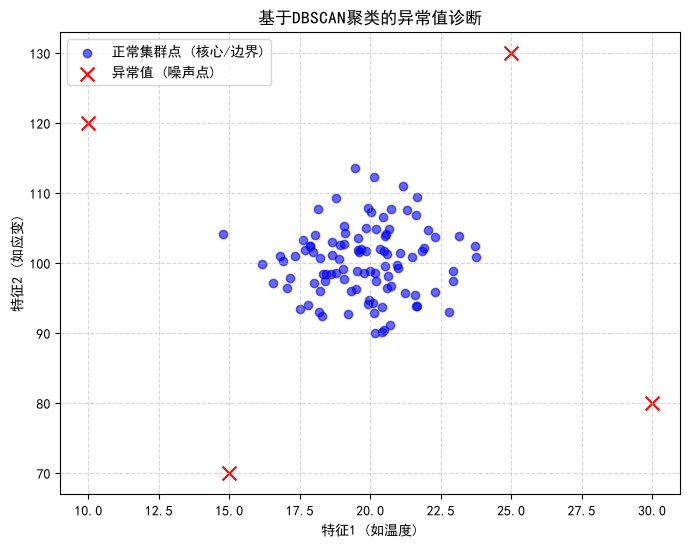

In [6]:
# 2.2 基于聚类的异常值诊断（DBSCAN）
print("=== 2.2 基于聚类的异常值诊断 (DBSCAN) ===")
# 生成二维模拟监测数据（例如：X轴为温度，Y轴为应变）
np.random.seed(42)
normal_data = np.random.normal(loc=[20, 100], scale=[2, 5], size=(100, 2))
outliers = np.array([[10, 120], [30, 80], [25, 130], [15, 70]]) # 注入异常点
X = np.vstack([normal_data, outliers])

# 使用DBSCAN进行聚类，离群点将被标记为 -1
dbscan = DBSCAN(eps=3.5, min_samples=5)
labels = dbscan.fit_predict(X)

# 提取正常点和异常点
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True
is_outlier = (labels == -1)

plt.figure(figsize=(8, 6))
plt.scatter(X[~is_outlier, 0], X[~is_outlier, 1], c='blue', label='正常集群点 (核心/边界)', alpha=0.6)
plt.scatter(X[is_outlier, 0], X[is_outlier, 1], c='red', marker='x', s=100, label='异常值 (噪声点)')
plt.title('基于DBSCAN聚类的异常值诊断')
plt.xlabel('特征1 (如温度)')
plt.ylabel('特征2 (如应变)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 3. 缺失数据恢复
本节演示：拉格朗日插值补全方法与基于压缩感知群稀疏优化的错误数据恢复（概念性简化演示）。

=== 3.1 拉格朗日插值补全方法 ===
已知点坐标 X: [1 2 3 4 5 7]
已知点坐标 Y: [2.1 2.  2.2 2.5 3.  2.7]
利用拉格朗日插值估计位置 x=6 处的缺失值为: 3.4667


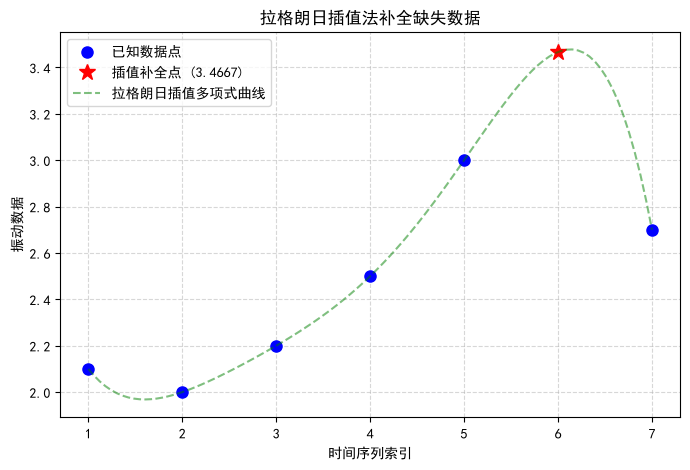

In [7]:
# 3.1 拉格朗日插值补全方法（教材例10-3）
print("=== 3.1 拉格朗日插值补全方法 ===")
# 原始数据：2.1, 2.0, 2.2, 2.5, 3.0, ?, 2.7
x_known = np.array([1, 2, 3, 4, 5, 7]) # 对应教材中 x0 到 x6，跳过缺失的索引6(值为x=6，由于教材中索引有点不同，我们用1,2,3,4,5,7作为横坐标)
y_known = np.array([2.1, 2.0, 2.2, 2.5, 3.0, 2.7])
x_missing = 6 # 缺失值的位置

# 使用scipy的lagrange函数构造插值多项式
poly = lagrange(x_known, y_known)
y_missing_est = poly(x_missing)

print(f"已知点坐标 X: {x_known}")
print(f"已知点坐标 Y: {y_known}")
print(f"利用拉格朗日插值估计位置 x={x_missing} 处的缺失值为: {y_missing_est:.4f}")

# 可视化
x_dense = np.linspace(1, 7, 100)
y_dense = poly(x_dense)

plt.figure(figsize=(8, 5))
plt.plot(x_known, y_known, 'bo', markersize=8, label='已知数据点')
plt.plot(x_missing, y_missing_est, 'r*', markersize=12, label=f'插值补全点 ({y_missing_est:.4f})')
plt.plot(x_dense, y_dense, 'g--', alpha=0.5, label='拉格朗日插值多项式曲线')
plt.title('拉格朗日插值法补全缺失数据')
plt.xlabel('时间序列索引')
plt.ylabel('振动数据')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

=== 3.2 压缩感知稀疏重构 (简化演示) ===


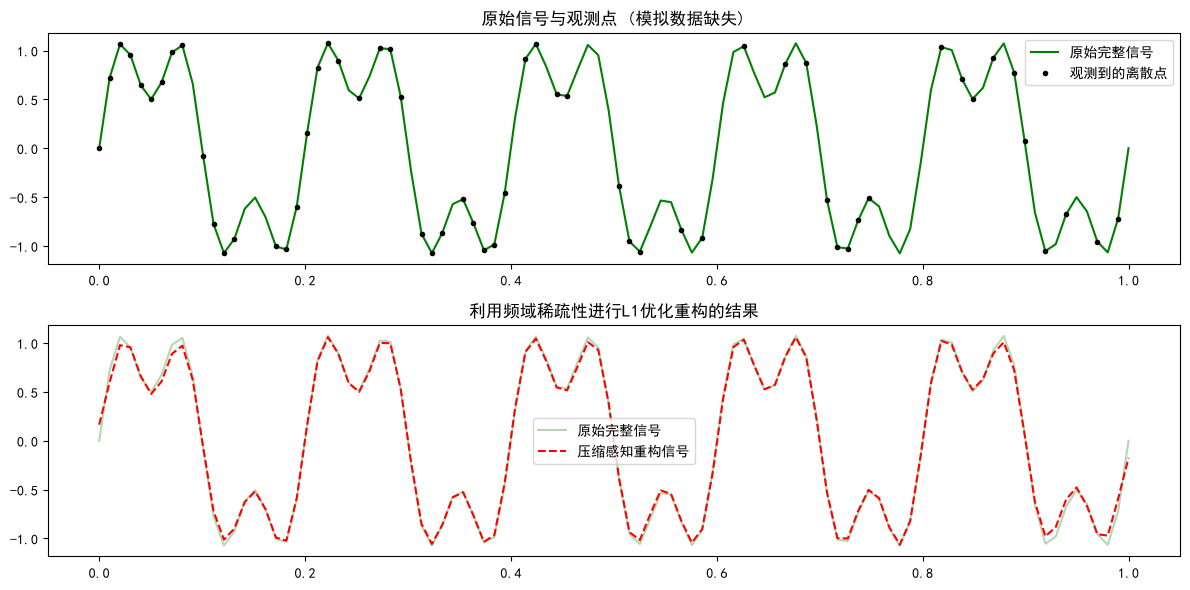

注：教材中针对多传感器测量矩阵采用了群稀疏(L2,1范数)优化模型，此处为便于展示使用了单传感器的一维L1范数压缩感知重构。原理一致。


In [8]:
# 3.2 基于压缩感知的稀疏重构演示（简化版：基于L1正则化的单维信号恢复）
print("=== 3.2 压缩感知稀疏重构 (简化演示) ===")
from scipy.optimize import minimize
from scipy.fftpack import dct, idct

# 构造稀疏信号：长度N=100，只有5个非零频率成分
N = 100
t = np.linspace(0, 1, N)
true_signal = np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 15 * t)

# 模拟数据丢失：随机丢失40%的数据
np.random.seed(0)
missing_mask = np.random.rand(N) > 0.4
observed_signal = true_signal.copy()
observed_signal[~missing_mask] = 0 # 丢失的数据置为0 (对应教材中的矩阵Z)

# 压缩感知重构目标函数：min ||X||_1 s.t. IDCT(X)[mask] = observed[mask]
# 这里使用无约束优化：min ||X||_1 + lambda * ||IDCT(X)[mask] - observed[mask]||_2^2
def objective(X, mask, y_obs, lam=10.0):
    # X是频域系数，idct(X)是时域信号
    x_time = idct(X, norm='ortho')
    fidelity = np.sum((x_time[mask] - y_obs[mask])**2)
    sparsity = np.sum(np.abs(X))
    return sparsity + lam * fidelity

# 初始猜测
X0 = np.zeros(N)
res = minimize(objective, X0, args=(missing_mask, observed_signal), method='L-BFGS-B')
X_rec = res.x
recovered_signal = idct(X_rec, norm='ortho')

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, true_signal, 'g-', label='原始完整信号')
plt.plot(t[missing_mask], observed_signal[missing_mask], 'k.', label='观测到的离散点')
plt.title('原始信号与观测点 (模拟数据缺失)')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t, true_signal, 'g-', alpha=0.3, label='原始完整信号')
plt.plot(t, recovered_signal, 'r--', label='压缩感知重构信号')
plt.title('利用频域稀疏性进行L1优化重构的结果')
plt.legend()
plt.tight_layout()
plt.show()
print("注：教材中针对多传感器测量矩阵采用了群稀疏(L2,1范数)优化模型，此处为便于展示使用了单传感器的一维L1范数压缩感知重构。原理一致。")